In [3]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import re
import numpy as np
import json
import urllib.request 
import glob
import seaborn as sns

# to keep my paths secret
import xscen as xs
from xscen import CONFIG
xs.load_config('paths.yml', verbose=(__name__ == '__main__'), reset=True)


In [37]:

import requests
import time
import pandas as pd



def get_datacite_citations(doi):
    url = f"https://api.datacite.org/dois/{doi}"
    try:
        r = requests.get(url)
        r.raise_for_status()
        data = r.json()
        return data["data"]["attributes"].get("citationCount", 0)
    except Exception as e:
        print(f"Error with {doi}: {e}")
        return None

path=f"{CONFIG['dir']}/citations/CMIP6_Data_References.csv"
df=pd.read_csv(path, encoding="latin1")
#df=df[df['EXPERIMENT_ID'].isnull()] # start with only source
results = []
for index, row in df.iterrows():
    doi=row['DOI'].replace('https://doi.org/','')
    results.append(get_datacite_citations(doi))
    
df['num_citation']=results
display(df)
df.to_csv(path)

Error with 10.5194/gmd-10-433-2017-supplement: 404 Client Error: Not Found for url: https://api.datacite.org/dois/10.5194/gmd-10-433-2017-supplement


,DRS_ID,MIP_ERA,ACTIVITY_ID,INSTITUTION_ID,SOURCE_ID,EXPERIMENT_ID,DOI,Data Reference,License,License Uri,num_citation
0,CMIP6.AerChemMIP.AS-RCEC.TaiESM1,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,NaN,https://doi.org/10.22033/ESGF/CMIP6.9682,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,3.0
1,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.hist-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,hist-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9744,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
2,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST,https://doi.org/10.22033/ESGF/CMIP6.9747,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
3,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9752,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
4,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.piClim-NTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,piClim-NTCF,https://doi.org/10.22033/ESGF/CMIP6.9790,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
...,...,...,...,...,...,...,...,...,...,...,...
3004,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10922,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3005,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.9949,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3006,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10923,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3007,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.1662,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,2.0


In [38]:
df.num_citation.sum()

27456.0

In [5]:
df_ref= pd.read_csv(f"{CONFIG['dir']}/citations/CMIP6_Data_References.csv")
df_ref

,Unnamed: 0,DRS_ID,MIP_ERA,ACTIVITY_ID,INSTITUTION_ID,SOURCE_ID,EXPERIMENT_ID,DOI,Data Reference,License,License Uri,num_citation
0,0,CMIP6.AerChemMIP.AS-RCEC.TaiESM1,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,NaN,https://doi.org/10.22033/ESGF/CMIP6.9682,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,3.0
1,1,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.hist-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,hist-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9744,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
2,2,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST,https://doi.org/10.22033/ESGF/CMIP6.9747,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
3,3,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9752,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
4,4,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.piClim-NTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,piClim-NTCF,https://doi.org/10.22033/ESGF/CMIP6.9790,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3004,3004,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10922,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3005,3005,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.9949,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3006,3006,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10923,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3007,3007,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.1662,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,2.0


In [8]:
#downloaded
df_source= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-sources_13_01_2025.csv")
display(df_source)
# published
df_model= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-models_13_01_2025.csv")
display(df_model)

,source_id_name,number_of_downloads,total_size_GB
0,EC-EARTH3,70435077,5091534.63
1,IPSL-CM6A-LR,2965261,3845623.97
2,MPI-ESM1-2-HR,6702396,3490023.05
3,CESM2,2925271,2611059.73
4,EC-EARTH3-VEG,26135094,2261190.15
...,...,...,...
140,PICLIM-BC,4,0.00
141,2BANDS,6,0.00
142,PICLIM-SO2,3,0.00
143,PICLIM-OC,3,0.00


,dimension,number_of_datasets,total_size_TB
0,4AOP-v1-5,12,0.00
1,ACCESS-CM2,49179,165.98
2,ACCESS-ESM1-5,323856,670.33
3,ACCESS-OM2,608,5.77
4,ACCESS-OM2-025,214,24.18
...,...,...,...
122,TaiESM1-TIMCOM,198,2.71
123,TaiESM1-TIMCOM2,169,2.28
124,UKESM1-0-LL,218607,743.47
125,UKESM1-1-LL,2445,6.44


In [18]:
df_source

,source_id_name,number_of_downloads,total_size_GB
0,EC-EARTH3,70435077,5091534.63
1,IPSL-CM6A-LR,2965261,3845623.97
2,MPI-ESM1-2-HR,6702396,3490023.05
3,CESM2,2925271,2611059.73
4,EC-EARTH3-VEG,26135094,2261190.15
...,...,...,...
140,PICLIM-BC,4,0.00
141,2BANDS,6,0.00
142,PICLIM-SO2,3,0.00
143,PICLIM-OC,3,0.00


# source

In [43]:
# sum all the only source data
df_refsource=df_ref[df_ref['EXPERIMENT_ID'].isnull()].groupby('SOURCE_ID')['num_citation'].sum().reset_index()
df_refsource
#align names
df_source=df_source.rename(columns={'source_id_name': 'SOURCE_ID', 'total_size_GB': 'total_size_GB_downloaded'})
df_model=df_model.rename(columns={'dimension': 'SOURCE_ID', 'total_size_TB':'total_size_TB uploaded'})
#merge
df_refsource= pd.merge(df_refsource,df_source, on='SOURCE_ID', )
df_refsource= pd.merge(df_model,df_refsource, on='SOURCE_ID')
df_refsource

,SOURCE_ID,number_of_datasets,total_size_TB uploaded,num_citation,number_of_downloads,total_size_GB_downloaded
0,ACCESS-CM2,49179,165.98,38.0,1078208,594693.43
1,ACCESS-ESM1-5,323856,670.33,61.0,2865244,1259006.45
2,ACCESS-OM2,608,5.77,4.0,14494,3446.97
3,ACCESS-OM2-025,214,24.18,3.0,30275,20201.69
4,ARTS-2-3,16,0.00,0.0,314,0.13
...,...,...,...,...,...,...
87,RRTMG-SW-4-02,4,0.00,0.0,91,0.04
88,RTE-RRTMGP-181204,8,0.00,0.0,44999,20.32
89,SAM0-UNICON,3250,29.73,7.0,531428,63298.90
90,UKESM1-0-LL,218607,743.47,70.0,1243827,965355.79


/tmp/ipykernel_2761476/1722520998.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.


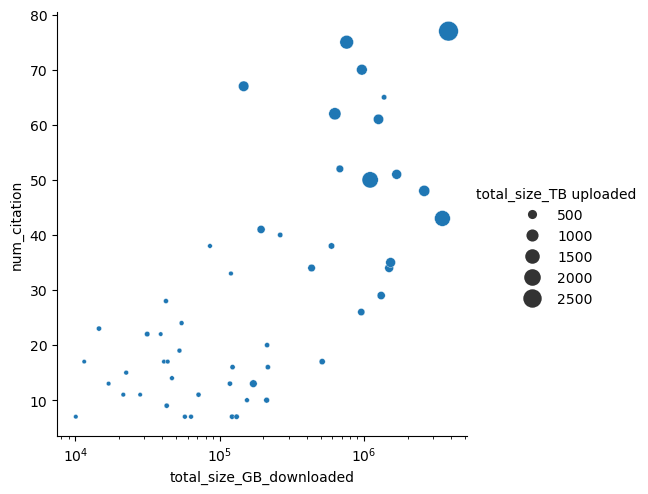

In [57]:



g = sns.relplot(
    data=df_refsource[df_refsource['num_citation']>5],
    x="total_size_GB_downloaded", y="num_citation", size="total_size_TB uploaded",
    sizes=(10, 200),
)


g.set(xscale="log",)

/tmp/ipykernel_2761476/4058505045.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.


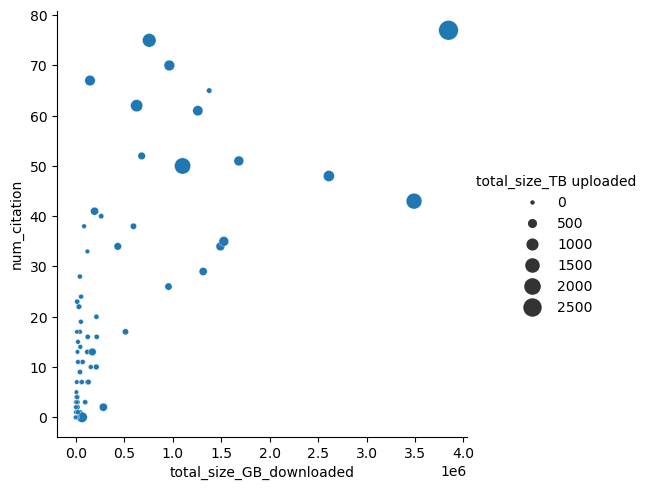

In [47]:
g = sns.relplot(
    data=df_refsource,
    x="total_size_GB_downloaded", y="num_citation", size="total_size_TB uploaded",
    palette=cmap, sizes=(10, 200),
)

# experiment

In [60]:
df_exp= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-experiments_13_01_2025.csv")
display(df_exp)
# sum all the only source data
df_refexp=df_ref[~df_ref['EXPERIMENT_ID'].isnull()].groupby('EXPERIMENT_ID')['num_citation'].sum().reset_index()
df_refexp
#align names
df_exp=df_exp.rename(columns={'experiment_name': 'EXPERIMENT_ID', 'total_size_GB': 'total_size_GB_downloaded'})
#merge
df_refexp= pd.merge(df_refexp,df_exp, on='EXPERIMENT_ID', )
df_refexp

,experiment_name,number_of_downloads,total_size_GB
0,historical,74948855,14301053.92
1,ssp585,18729733,4676138.99
2,ssp245,43389071,4272423.51
3,picontrol,20309730,3931228.96
4,ssp126,10923775,2475419.44
...,...,...,...
265,ssp585-future-methane,4,0.02
266,ssp126-future-methane,13,0.01
267,ssp370-future-methane,6,0.01
268,ssp119-future-methane,1,0.01


,EXPERIMENT_ID,num_citation,number_of_downloads,total_size_GB_downloaded
0,abrupt-solm4p,0.0,4230,3705.70
1,abrupt-solp4p,0.0,5682,4415.05
2,amip,464.0,1527968,984812.30
3,amip-hist,65.0,43135,21511.14
4,amip-hld,0.0,412,149.36
...,...,...,...,...
70,ssp585-withism,0.0,3834,836.36
71,volc-long-eq,1.0,4538,433.36
72,volc-pinatubo-full,0.0,7531,151.26
73,volc-pinatubo-strat,0.0,1107,21.04


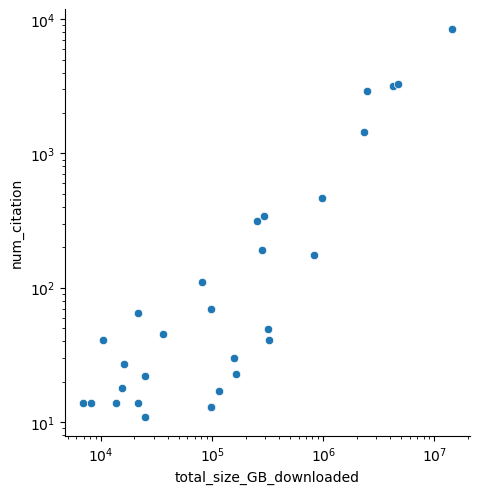

In [66]:
g = sns.relplot(
    data=df_refexp[df_refexp['num_citation']>10],
    x="total_size_GB_downloaded", y="num_citation",
)


g.set(xscale="log",yscale='log')